<a href="https://colab.research.google.com/github/Yayago938/Synapse-Learning-Phase/blob/week3/Copy_of_SynapseLP_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 3**

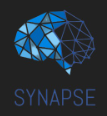

# Unsupervised Learning: Clustering, Dimensionality Reduction, and Association Rules

Unsupervised learning can be broken down into three main tasks:

- **Clustering**  
- **Dimensionality Reduction**  
- **Association Rules**  

Let's explore these topics :))  

Clustering is an unsupervised learning technique used to group similar data points together. It's widely used in applications like customer segmentation, anomaly detection, and more. In this task, we'll explore different clustering algorithms and visualize their results.  

Dimensionality reduction is a technique used to reduce the number of features in a dataset while retaining most of the important information. This helps in better visualization, faster computation, and noise reduction.  

Association rules are used to discover interesting relationships between variables in large datasets. A common example is market basket analysis, where we find products that are frequently bought together.  

In this task, we'll work with the **Online Retail dataset**, which contains transactional data from an e-commerce retailer. We'll use this dataset to:

- Cluster customers based on their purchasing behavior.  
- Reduce feature dimensions for visualization using PCA.  
- Discover associations between products using association rule mining.  


In [2]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# For clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
# For association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# For interactive widgets
from ipywidgets import interact
# Misc
import warnings
warnings.filterwarnings("ignore")

Use the Online retail dataset for this task:https://drive.google.com/drive/folders/1jZMLVW7LboD95K-HznZSsVUwrC-k-QOG?usp=sharing

Mount the drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Online_Retail.csv", encoding='latin1') #Add the path in the ""

Understanding the data

In [5]:
# print 1st few rows of the dataset, its shape and the columns
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
(541909, 8)
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853 

In [6]:
# check for null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Analyse the Missing Values

From the previous output, we observe:
- `Description` has **1454 missing values** — this is a small amount compared to the total rows. Since association rules require product names, we will **drop rows with missing `Description`**.
- `CustomerID` has **135080 missing values**, which is a large amount. Whether to keep or drop these rows depends on our analysis:
  - If we want to do **customer-level analysis or clustering**, we must have `CustomerID`. In that case, we will **drop rows where `CustomerID` is missing**.
  - If we only want **product-level analysis** (e.g., frequent items), we can keep them.
  
In this task, we will proceed with **customer-level analysis**, so we will **drop rows where `CustomerID` is missing**.


In [7]:
#Drop the rows with missing\null values
df.dropna(subset=['CustomerID'], inplace=True)
#Re-check the shape and missing values
print(df.shape)
df.isnull().sum()

(406829, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [8]:
# Remove rows with negative or zero Quantity
df.drop(df[df['Quantity'] <= 0].index, inplace=True)
# Remove rows with zero or negative UnitPrice
df.drop(df[df['UnitPrice'] <= 0].index, inplace=True)
# Remove cancelled invoices (those starting with 'C')
df.drop(df[df['InvoiceNo'].str.startswith('C')].index, inplace=True)


In [9]:
# Verify there are no negative values left
num_df = df.select_dtypes(include='number')
print((num_df < 0).any().any())
# Quick summary after cleaning
df.describe()

False


,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [10]:
# Check how many duplicate rows exist
df.duplicated().sum()

np.int64(5192)

In [11]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
# Check again
df.duplicated().sum()
# Verify again


np.int64(0)

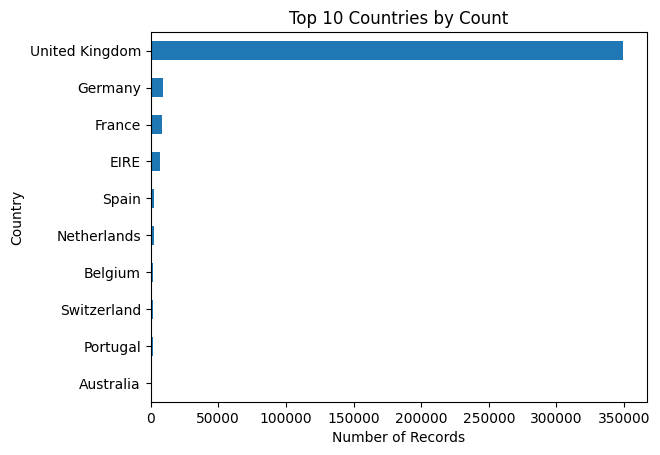

In [12]:
# Identify the top 10 countries with the highest number of transactions
top_countries = df['Country'].value_counts().head(10)
# Hint: Use a **horizontal bar chart** to visualize the results.
plt.figure()
top_countries.sort_values().plot(kind='barh')

# Labels & title
plt.xlabel('Number of Records')
plt.ylabel('Country')
plt.title('Top 10 Countries by Count')

# Show plot
plt.show()

Pre-Processing the data for PCA and clustering

In [13]:
#Create a new TotalAmount column(Quantity * Unit price)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
# Aggregate numeric data at the customer level

customer_df = df.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum'
}).reset_index()

# Keep only numeric columns for PCA
df_pca = customer_df.select_dtypes(include='number')

In [14]:
#Standardize the numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

Now that you have understood how to preprocess data for PCA through Online Retail dataset, we will apply similar steps to a new dataset: the Customer dataset.

This will help reinforce your understanding of dimensionality reduction and Clustering, while working with a dataset that is easier to visualize in 2D and 3D.

From this point onward, we will use the Customer_Data dataset:https://drive.google.com/drive/folders/1jZMLVW7LboD95K-HznZSsVUwrC-k-QOG?usp=sharing

In [15]:
# Load the dataset
df_2= pd.read_csv("/content/drive/MyDrive/Customer_Data.csv") # Continue with the routine

In [16]:
#Check for missing values
df_2.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONE_OFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONE_OFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [17]:
#Drop CUST_ID (identifier, not useful for PCA)
df_2.drop('CUST_ID', axis=1, inplace=True)

In [18]:
#Handle missing values if needed
# Option: fill missing values with median (common in financial datasets)
df_2.fillna(df_2.median(), inplace=True)

Explain
Why did we fill the missing values in this dataset instead of dropping them, like we did in the previous dataset?

Answer: In the customer details dataset the columns having missing values are numeric and they can be filled with the median , however if we drop the rows having null values we will lose customer information. In the online retail dataset we dropped the rows because not knowing a customer ID makes it difficult for us to associate that order to a customer thus making that info redundant and of no use.

In [19]:
#Standardize numeric features
scaler = StandardScaler()
df_2_scaled = scaler.fit_transform(df_2)

In [20]:
#Verify scaled data
df_2_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.0932934 ,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.32687479,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.33830497,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.3243581 ,
        -0.52555097, -4.12276757]])

# Dimensionality Reduction using PCA - Principal Component Analysis

Ref.: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Theory: https://towardsdatascience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643 and https://rlrocha.medium.com/choosing-the-number-of-components-of-principal-component-analysis-36902a887520

Theory + Implementation.: https://youtu.be/OFyyWcw2cyM (Jump to timestamp - 13:50 for PCA implementaion)

Before we start of with this, **explain what PCA is and why is it necessary?**

Answer:PCA(Principal Component Analysis) is a feature extraction technique where we calculate a covariance matrix of all the features after standardisation and then find the eigen values and eigen vectors for that matrix . The highest eigen value corresponds to the Principal Component 1 and then the order of the eigen values follows . We do this so that we can reduce the number of dimensions . In PCA we find the best fit line that captures maximum variance . Here variance is our cost function and we want to maximize variance . By doing PCA we can extract the influence of the features by combining them and then perform ML operations on those reduced and mixed features .

Reduce the number of dimensions using PCA,

Hints:
1. Initialise instance of PCA and set *n_components* to 0.9 and *random_state* to 20.
2. Fit X_scaled over the PCA instance created
3. Transform X_scaled over the fitted PCA instance and store it in a variable named data_pca.

In [21]:
#Code here
from sklearn.decomposition import PCA
pca=PCA(n_components=0.9,random_state=20)
pca.fit(df_2_scaled)
data_pca=pca.transform(df_2_scaled)

In [22]:
# Check the shape of the transformed data
data_pca.shape
#If everything's correct should print (8950,10)

(8950, 10)

Go through these and display the explained_variance_ratio_ and plot the same

Ref: https://saturncloud.io/blog/what-is-sklearn-pca-explained-variance-and-explained-variance-ratio-difference/ and https://www.jcchouinard.com/pca-explained-variance/

In [23]:
# Explained variance ratio
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.27297671 0.2031378  0.08813182 0.07479524 0.06224729 0.05740056
 0.04883426 0.04299203 0.03798259 0.03080002]
0.9192983251776005


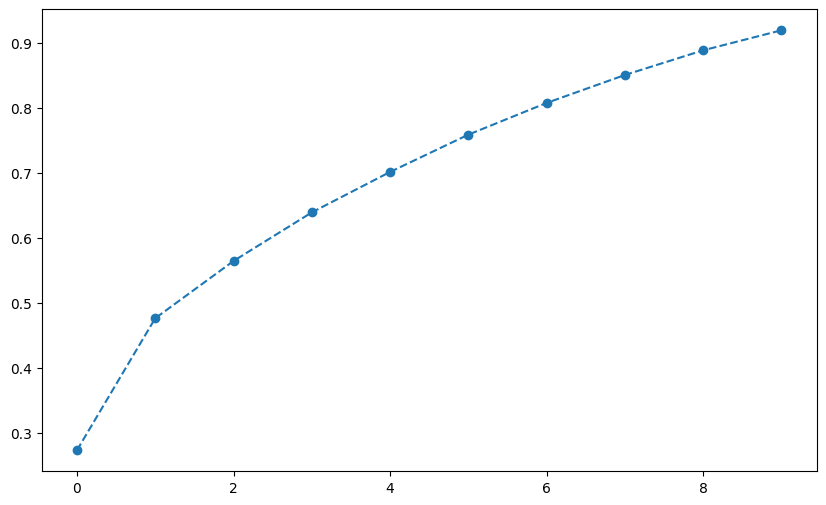

In [24]:
# Plotting the explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')

What did you understand by Explained Variance

Answer:Explained variance shows the absolute variance captured by the principal component while the explained variance ratio shows the percent of total variance captured by the component.

# K-Means Clustering (Partition-Based Clustering)

K-means clustering is an essential partitioning algorithm used to categorize a dataset into 'k' distinct, non-overlapping clusters. Each data point is assigned to the cluster with the nearest mean or centroid, symbolizing the cluster's center. The primary goal of the algorithm is to minimize the sum of squared distances between data points and their respective cluster centroids.

For an in-depth exploration of K-means clustering, you can refer to this comprehensive article on Analytics Vidhya: [Comprehensive Guide to K-means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/).

For a deeper understanding of the mathematical underpinnings of K-means clustering, Wikipedia is a valuable resource. You can explore the Wikipedia page on K-means clustering for a detailed description: [K-means Clustering Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering). This will help you grasp the mathematical intricacies of the algorithm and its applications in machine learning.

Here are some more resources to help you understand these concepts in depth:https://www.youtube.com/watch?v=4b5d3muPQmA

2D Visualization


In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from ipywidgets import interact

# Function to perform K-Means and plot clusters
def kmeans_clustering(num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(data_pca)

    plt.figure(figsize=(8,6))
    # Plot the first 2 principal components
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', alpha=0.7)
    # Plot centroids
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'K-Means Clustering ({num_clusters} clusters)')
    plt.legend()
    plt.show()

# Interactive widget to choose number of clusters
interact(kmeans_clustering, num_clusters=(1, 10, 1))


interactive(children=(IntSlider(value=5, description='num_clusters', max=10, min=1), Output()), _dom_classes=(…

<function __main__.kmeans_clustering(num_clusters)>

3D Visualization

In [26]:
def kmeans_3d_clustering(num_clusters):
    kmeans_3d = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_3d_labels = kmeans_3d.fit_predict(data_pca)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=kmeans_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Kmeans Clustering (3D)')
    plt.show()

interact(kmeans_3d_clustering, num_clusters=(1, 6, 1))

interactive(children=(IntSlider(value=3, description='num_clusters', max=6, min=1), Output()), _dom_classes=('…

<function __main__.kmeans_3d_clustering(num_clusters)>

# Elbow Point

The "elbow point" is a concept often used in the context of K-means clustering to help determine the optimal number of clusters (k) for a given dataset. It is a graphical method that can assist data analysts and machine learning practitioners in finding an appropriate value for k when applying K-means clustering.

The rationale behind the elbow point method is that as you increase the number of clusters (k), the sum of squared distances will generally decrease because data points will be closer to their respective cluster centroids. However, beyond a certain point, subdividing the data into more clusters doesn't provide significant improvements in reducing the sum of squared distances. The elbow point represents that optimal trade-off between the number of clusters and the compactness of each cluster.

It's important to note that the elbow point method is a heuristic and not a foolproof method for determining the ideal k value. In some cases, the elbow point may not be very pronounced, making it challenging to choose the best k. Additionally, the choice of k should also consider domain knowledge and the specific goals of your analysis.


For a clearer and more intuitive explanation of this topic, you can refer to the following video::https://www.youtube.com/watch?v=5shTLzwAdEc (Jump to timestamp 14:28 for elbow method)

Elbow Method to determine the number of clusters to be formed:


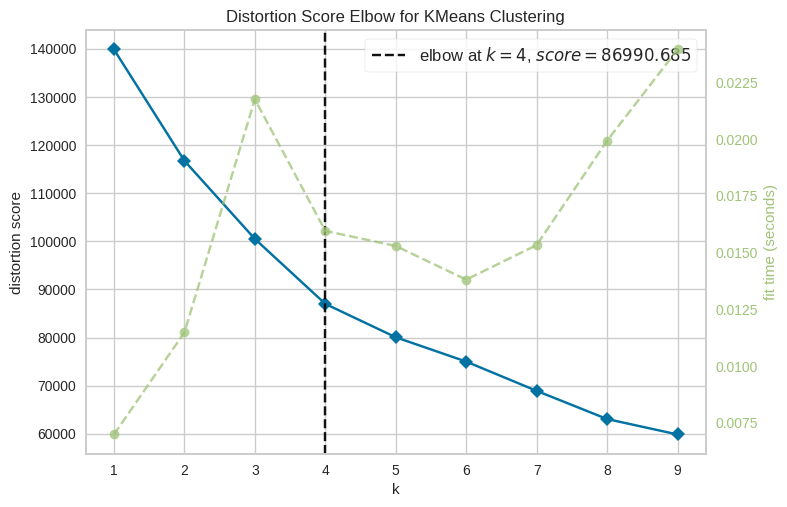

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

print('Elbow Method to determine the number of clusters to be formed:')

Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=(1, 10))
Elbow_M.fit(data_pca)
Elbow_M.show()


# Agglomerative Clustering

It is a hierarchical clustering algorithm used in unsupervised machine learning and data analysis. It is a "bottom-up" or "agglomerative" approach to clustering, where individual data points are initially treated as their own clusters and then progressively merged into larger clusters based on a similarity or distance metric. The result is a tree-like structure called a dendrogram that represents the hierarchical relationships between clusters.

As always, You can find more detailed information about hierarchical clustering, including agglomerative clustering, in the Wikipedia article on "Hierarchical clustering" at the following link: [Hierarchical Clustering Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering). This is the best resource for hierarchical clustering and it is advisable to go through it twice if possible! :)

More ref: https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/

**2 Dimensional Visualization**

In [28]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from ipywidgets import interact

# Function for Agglomerative Clustering
def agglomerative_clustering(num_clusters):
    # Fit Agglomerative Clustering on PCA-reduced data
    agglomerative = AgglomerativeClustering(
        n_clusters=num_clusters,
        linkage='average'
    )

    # Use PCA data for clustering
    agglomerative_labels = agglomerative.fit_predict(data_pca)

    # Plot clusters (2D using first 2 principal components)
    plt.figure(figsize=(8, 6))
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=agglomerative_labels, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'Agglomerative Clustering (k={num_clusters})')
    plt.show()

# Interactive slider (FIXED)
interact(agglomerative_clustering, num_clusters=(2, 10, 1))

interactive(children=(IntSlider(value=6, description='num_clusters', max=10, min=2), Output()), _dom_classes=(…

<function __main__.agglomerative_clustering(num_clusters)>

Similar to classification and regression metrics, we have some [clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) to evaluate performance.

We wll explore one of them: [silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Perform Agglomerative Clustering with 3 clusters
agglo = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agglo.fit_predict(data_pca)  # or use data_pca if you want PCA-reduced data

# Calculate Silhouette Score
silhouette = silhouette_score(data_pca, labels)  # or data_pca
print("Silhouette Score for 3 clusters:", silhouette)


Silhouette Score for 3 clusters: 0.8387829170309258


Explain Silhoutte score
Silhouette Score

Measures how well each data point fits within its cluster compared to other clusters.

Uses: average intra-cluster distance (a) and nearest-cluster distance (b)

Formula: (b − a) / max(a, b)

Range: -1 to 1

Interpretation:

Close to 1 → well-separated clusters

Around 0 → overlapping clusters

Negative → wrong clustering

Look into any 2 other metrics and give a brief explanation.



Do it here :)

Inertia (WCSS – Within Cluster Sum of Squares)

Measures how tightly the data points are grouped within clusters.

It is the sum of squared distances between each point and its cluster centroid

Range: 0 to ∞ (lower is better)

Interpretation:

Lower inertia → compact clusters

Always decreases as number of clusters increases

Used in: Elbow Method

Dunn Index

Measures cluster quality by comparing separation vs compactness.

Formula: (minimum inter-cluster distance) / (maximum intra-cluster distance)

Range: 0 to ∞ (higher is better)

Interpretation:

High value → clusters are well-separated and compact

Low value → clusters overlap or are spread out

**3 Dimensional Visualization**

In [30]:
# from mpl_toolkits.mplot3d import Axes3D

# Function for 3D Agglomerative Clustering
def agglomerative_clustering(num_clusters):
    # Fit Agglomerative Clustering on PCA-reduced data
    agglomerative = AgglomerativeClustering(
        n_clusters=num_clusters,
        linkage='average'
    )

    # Fit Agglomerative Clustering
    agglomerative_labels = agglomerative.fit_predict(data_pca)
    # using PCA data

    # 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=agglomerative_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Agglomerative Clustering (3D)')
    plt.show()
# Interactive widget
interact(agglomerative_clustering, num_clusters=(2,10 ,1))#fill here


interactive(children=(IntSlider(value=6, description='num_clusters', max=10, min=2), Output()), _dom_classes=(…

<function __main__.agglomerative_clustering(num_clusters)>

Look into what dendrograms are and plot them here.

Ref: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

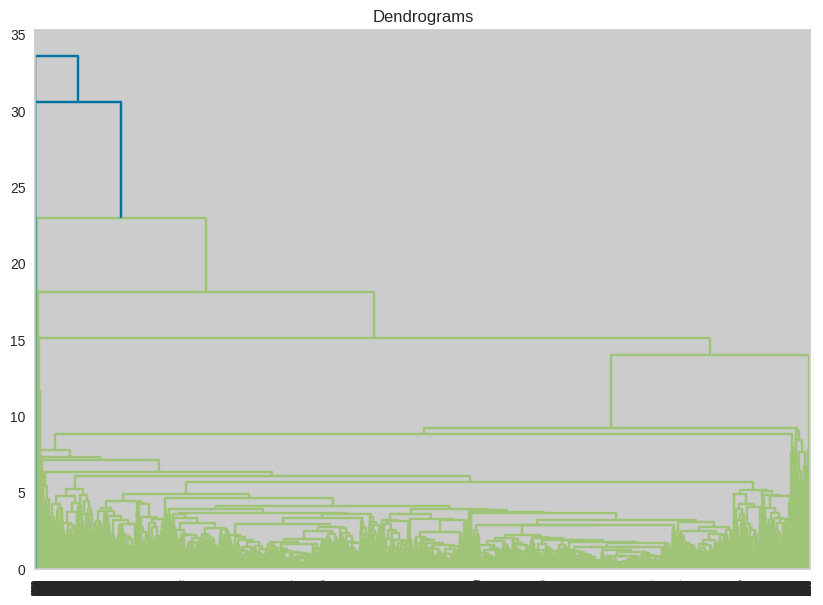

In [34]:
#plot here

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_pca, method='average'))

# DBSCAN Clustering

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a popular density-based clustering algorithm in unsupervised machine learning. It is particularly useful for discovering clusters of arbitrary shapes in datasets with varying levels of data density. DBSCAN is known for its ability to handle noise and outliers effectively.

As always, You can find additional information about how DBSCAN clustering works in the following article on Analytics Vidhya:

[How DBSCAN Clustering Works](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/#:~:text=DBSCAN%20is%20a%20density%2Dbased,points%20into%20a%20single%20cluster.)

This article provides a detailed explanation of DBSCAN, including its underlying concepts, the role of epsilon (ε) and minimum points (MinPts), and practical examples of how to use DBSCAN for clustering. It's a valuable resource for gaining a deeper understanding of the algorithm with Wikipedia as the side resource.

Take a look at this short video to gain a better understanding of the concept:https://www.youtube.com/watch?v=RDZUdRSDOok

**2 Dimensional Visualization**

In [35]:
# Perform DBSCAN clustering with interactive widget
def dbscan_clustering(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(data_pca)#code here

    #plot here
    plt.figure(figsize=(8, 6))
    plt.scatter(data_pca[:,0],data_pca[:,1],c=dbscan_labels,cmap='viridis',edgecolors='k')
# Interactive widget
interact(dbscan_clustering, eps=(2,10,1 ),min_samples=(11,20 ,1 )) #fill here

interactive(children=(IntSlider(value=6, description='eps', max=10, min=2), IntSlider(value=15, description='m…

<function __main__.dbscan_clustering(eps, min_samples)>

**3 Dimensional Visualization**

In [39]:
def dbscan_3d_clustering(eps, min_samples):
    #Write the complete function yourself
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(data_pca)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=dbscan_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title(' DBSCAN Clustering (3D)')
    plt.show()
# Interactive widget
interact(dbscan_3d_clustering, eps=(2,10,1 ),min_samples=(11,20 ,1 ))


interactive(children=(IntSlider(value=6, description='eps', max=10, min=2), IntSlider(value=15, description='m…

<function __main__.dbscan_3d_clustering(eps, min_samples)>

After performing K-Means and Agglomerative clustering on the dataset, what differences and similarities did you notice between the two methods? What insights did you gain from the cluster patterns?

Answer:
Similarities

Cluster Grouping Pattern

Both methods often group major dense regions similarly.

If your data has well-separated clusters, K-Means and Agglomerative will produce almost identical results.

Dependence on Distance

Both rely heavily on distance metrics (usually Euclidean).

So clusters tend to be compact and centered around dense areas.

Same Optimal Cluster Count (sometimes)

If you chose k = 3, both methods may show similar cluster boundaries for dominant groups.
Differences

Cluster Shape

K-Means → Assumes spherical (round) clusters

Agglomerative → Can capture irregular shapes and hierarchical structure

Approach

K-Means → Centroid-based (top-down optimization)

Agglomerative → Bottom-up merging (hierarchical)

Flexibility

Agglomerative is more flexible due to:

Different linkages (ward, average, complete)

K-Means is rigid → struggles with non-convex clusters

Sensitivity

K-Means

Sensitive to initial centroid placement

Sensitive to outliers

Agglomerative

Less sensitive to initialization

But can be affected by noise depending on linkage

Cluster Boundaries

K-Means → Sharp, clean boundaries

Agglomerative → More natural / uneven splits

# **Bonus: To be done only if you have completed the above tasks.**

In this task, we covered clustering and Dimensionality reduction. But still, one aspect of Unsupervised Learning is left to be covered- **Association rules**. Reseach about this topic and mention the different algos that exist.

 Also, look into the functioning of **Spectral Clustering algorithm** and mention it here :)

 The best reseach will be edited and featured on the Synapse Instagram page!!

Association (or association rule mining) is a technique in data mining used to discover interesting relationships or patterns between variables in large datasets.
Key Metrics in Association Rules
Support: How frequently an itemset appears in transactions.
Write on Medium
Support(A)= Transactions containing A / Total transactions​

2. Confidence: How often item B appears when item A appears.

Confidence(A⇒B)= Support(A∪B) / Support(A)

3. Lift: Strength of the rule compared to random chance.

Lift(A⇒B)= Confidence(A⇒B) / Support(B)
​
Lift > 1 → A and B are positively correlated.
Lift = 1 → A and B have no correlation.
Lift < 1 → A and B are negatively correlated.

Algorithms used: Apriori, FP-Growth and ECLAT,etc.

 Spectral Clustering

Definition

Spectral Clustering is a technique that clusters data by converting it into a graph structure and using eigenvalues and eigenvectors of a matrix to group similar data points.

 Key Idea

Instead of using distance directly (like K-Means), it:

Builds a similarity graph

Finds a better representation of data

Then applies a simple clustering method (like K-Means)

 Steps of Spectral Clustering
 Construct Similarity Matrix (W)

Measure similarity between every pair of points

Example: Gaussian similarity

 Construct Degree Matrix (D)

Diagonal matrix

Each value = sum of similarities of a point

 Compute Laplacian Matrix (L)
L = D - W

 This captures the structure of the graph

 Compute Eigenvalues & Eigenvectors

Find eigenvectors corresponding to smallest eigenvalues

These represent the true structure of data

 Form New Feature Space

Use selected eigenvectors to represent data points

 Apply K-Means

Perform clustering on the transformed data

 Why it works

It groups points such that:

Points within a cluster are highly connected

Points in different clusters are weakly connected

 Advantages

Can detect non-linear and complex shapes

Works well when clusters are not spherical

 Disadvantages

Computationally expensive

Not suitable for very large datasets

Once you’ve completed all the tasks, feel free to make your submission even more impressive by adding sample code implementations or practical examples that demonstrate these algorithms in action.

# **End of Task**

> ©DJS Synapse 2025 - 2026